# 19 — Les lignes de base, et la frontière exacte qui les juge

Le filtre proposé par ce dépôt n'a jamais été comparé qu'à un seul adversaire : le classement
par pertinence pure, dont il se distingue **par construction**. Personne ne lui a demandé s'il
faisait mieux qu'une heuristique triviale — servir les points de vue à tour de rôle, tirer au
sort, ou appliquer la diversification standard de la recherche d'information.

C'est la dette la plus ancienne du programme d'évaluation, et elle ne demande aucune donnée
nouvelle : elle se règle par énumération.

**Le protocole.** Un fil se juge sur deux grandeurs en tension — l'engagement produit et la
diversité exposée, toutes deux pondérées par l'attention de chaque rang. Un réordonnanceur
n'est donc ni bon ni mauvais : il occupe un point du plan, et la seule question qui vaille est
**de combien il rate la frontière atteignable**. Cette frontière n'est pas estimée ici, elle
est **calculée exactement** : tous les arrangements ordonnés de six contenus tirés d'un vivier
de dix sont énumérés.

**Ce que ce notebook établit :**

* le filtre du dépôt se tient **sur la frontière** — manque à gagner médian de $0{,}0$ à
  $1{,}0\ \%$ selon le plancher — et c'est ce qu'on lui demandait de démontrer ;
* **il n'est pas seul, ni premier** : MMR, publié en 1998, y est aussi à tous les planchers, de
  $0{,}0$ à $0{,}2\ \%$. La nouveauté de ce dépôt n'est pas dans son filtre ;
* la différence n'est pas dans le coût mais dans la **capacité à atteindre la contrainte** : au
  plancher $0{,}90$, MMR ne trouve aucun réglage conforme dans **47 %** des viviers, contre
  **12 %** pour le filtre entropique ;
* le tirage au sort atteint les planchers sans peine — c'est la méthode qui échoue le moins —
  mais il laisse **9 à 19 %** d'engagement sur la table pour y arriver ;
* et le **prix de la norme dépend du lecteur** : un plancher de $0{,}90$ coûte $3{,}8\ \%$
  d'engagement quand la pertinence est indépendante du point de vue, et **$17{,}1\ \%$** quand
  elle en découle entièrement. La norme coûte le plus cher là où elle sert le plus.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from ide.baselines import (
    Pool,
    best_under_floor,
    boltzmann_ranking,
    engagement_ranking,
    entropic_ranking,
    evaluate,
    evaluate_many,
    exact_frontier,
    frontier,
    mmr_ranking,
    random_ranking,
    reachable_engagement,
    round_robin_ranking,
    shortfall,
)
from ide.plotting import PALETTE, save_figure, use_project_style

use_project_style()

SLOTS, POOL_SIZE, CATALOGUE = 6, 10, 4
FLOORS = (0.5, 0.6, 0.7, 0.8, 0.9)
DRAWS = 150

METHODS = ("tour de rôle", "MMR", "Boltzmann", "filtre entropique", "aléatoire")
COLOURS = {
    "tour de rôle": PALETTE["neutral"],
    "MMR": PALETTE["field"],
    "Boltzmann": PALETTE["order"],
    "filtre entropique": PALETTE["remedy"],
    "aléatoire": PALETTE["disorder"],
}


def sweeps_for(pool, seed):
    # Le balayage de paramètre de chaque méthode : une courbe, pas un point.
    return {
        "tour de rôle": frontier(
            lambda cycles, p=pool: round_robin_ranking(p, SLOTS, int(cycles)),
            range(SLOTS + 1), pool),
        "MMR": frontier(
            lambda trade_off, p=pool: mmr_ranking(p, SLOTS, trade_off),
            np.linspace(0.0, 1.0, 21), pool),
        "Boltzmann": frontier(
            lambda setting, p=pool: boltzmann_ranking(
                p, SLOTS, setting[0], np.random.default_rng(int(setting[1]))),
            [(temperature, seed * 10 + draw)
             for temperature in (0.03, 0.08, 0.15, 0.3, 0.6, 1.2) for draw in range(3)], pool),
        "filtre entropique": frontier(
            lambda mu, p=pool: entropic_ranking(p, SLOTS, mu),
            (0.0, 0.05, 0.1, 0.25, 0.5, 1.0, 2.0, 4.0, 8.0, 16.0), pool),
        "aléatoire": frontier(
            lambda draw, p=pool: random_ranking(p, SLOTS, np.random.default_rng(int(draw))),
            range(seed * 20, seed * 20 + 18), pool),
    }


def draw_pool(rng, alignment=0.0):
    # Un vivier de contenus ; alignment = part de la pertinence expliquée par le point de vue.
    preference = np.linspace(1.0, 0.15, CATALOGUE)
    viewpoints = rng.integers(0, CATALOGUE, POOL_SIZE)
    if np.unique(viewpoints).size < 2:
        viewpoints[0] = (viewpoints[0] + 1) % CATALOGUE
    idiosyncratic = rng.uniform(0.15, 1.0, POOL_SIZE)
    relevance = alignment * preference[viewpoints] + (1.0 - alignment) * idiosyncratic
    return Pool(viewpoints=viewpoints, relevance=relevance, catalogue_size=CATALOGUE)


print(f"{POOL_SIZE} contenus, {SLOTS} positions, {CATALOGUE} points de vue")
print(f"arrangements énumérés par vivier : {np.math.perm(POOL_SIZE, SLOTS) if hasattr(np, 'math') else 151200}")

10 contenus, 6 positions, 4 points de vue
arrangements énumérés par vivier : 151200


## 1. Un vivier, la frontière, et les cinq méthodes

Chaque point gris est un fil possible. La courbe est la **frontière exacte** : à chaque niveau
de diversité exposée, le meilleur engagement atteignable. Aucune méthode ne peut passer
au-dessus ; la seule question est de savoir à quelle distance elle passe en dessous.

In [2]:
example = draw_pool(np.random.default_rng(11))
front = exact_frontier(example, SLOTS)

import itertools
sample = np.array(list(itertools.islice(itertools.permutations(range(POOL_SIZE), SLOTS), 0, None, 7)))
cloud_exposure, cloud_engagement = evaluate_many(example, sample)

reference = evaluate(example, engagement_ranking(example, SLOTS))
example_sweeps = sweeps_for(example, 0)

print(f"fils possibles : {np.math.perm(POOL_SIZE, SLOTS) if hasattr(np, 'math') else 151200}, "
      f"dont {len(front)} sur la frontière")
print(f"classement par pertinence : diversité {reference.exposure:.3f}, "
      f"engagement {reference.engagement:.3f}\n")
print(f"{'méthode':20s} {'meilleur fil à diversité ≥ 0,80':>32s} {'manque à gagner':>17s}")
print("-" * 72)
for name in METHODS:
    choice = best_under_floor(example_sweeps[name], 0.80)
    if choice is None:
        print(f"{name:20s} {'plancher jamais atteint':>32s} {'—':>17s}")
    else:
        print(f"{name:20s} {choice.engagement:32.3f} {100 * shortfall(choice, front):16.1f}%")

fils possibles : 151200, dont 15 sur la frontière
classement par pertinence : diversité 0.779, engagement 2.027

méthode               meilleur fil à diversité ≥ 0,80   manque à gagner
------------------------------------------------------------------------
tour de rôle                                    1.948              2.1%
MMR                                             1.990              0.0%
Boltzmann                                       1.494             25.1%
filtre entropique                               1.990              0.0%
aléatoire                                       1.503             24.6%


## 2. Sur 150 viviers tirés au sort

Comparer les méthodes là où chacune tombe serait injuste : leurs paramètres ne se
correspondent pas. On fixe donc le **plancher** et l'on demande à chacune ce qu'elle sait faire
de mieux en s'y conformant — exactement la question que pose un régulateur.

In [3]:
shortfalls = {name: {floor: [] for floor in FLOORS} for name in METHODS}
failures = {name: {floor: 0 for floor in FLOORS} for name in METHODS}
eligible = {floor: 0 for floor in FLOORS}
price = {floor: [] for floor in FLOORS}
duel = {floor: [0, 0, 0] for floor in FLOORS}

rng = np.random.default_rng(2026)
for draw in range(DRAWS):
    pool = draw_pool(rng)
    pool_front = exact_frontier(pool, SLOTS)
    unconstrained = evaluate(pool, engagement_ranking(pool, SLOTS)).engagement
    sweeps = sweeps_for(pool, draw)

    for floor in FLOORS:
        best_possible = reachable_engagement(pool_front, floor)
        if not np.isfinite(best_possible):
            continue
        eligible[floor] += 1
        price[floor].append(1.0 - best_possible / unconstrained)

        choices = {}
        for name in METHODS:
            choice = best_under_floor(sweeps[name], floor)
            choices[name] = choice
            if choice is None:
                failures[name][floor] += 1
            else:
                shortfalls[name][floor].append(1.0 - choice.engagement / best_possible)

        filtered, standard = choices["filtre entropique"], choices["MMR"]
        if filtered is None and standard is None:
            continue
        if standard is None or (filtered is not None
                                and filtered.engagement > standard.engagement + 1e-9):
            duel[floor][0] += 1
        elif filtered is None or standard.engagement > filtered.engagement + 1e-9:
            duel[floor][1] += 1
        else:
            duel[floor][2] += 1

print("Manque à gagner médian, parmi les viviers où la méthode atteint le plancher\n")
print(f"{'méthode':20s}" + "".join(f"{floor:>11.2f}" for floor in FLOORS))
print("-" * (20 + 11 * len(FLOORS)))
for name in METHODS:
    row = "".join(
        f"{100 * np.median(shortfalls[name][floor]):10.1f}%" if shortfalls[name][floor]
        else f"{'—':>11s}" for floor in FLOORS)
    print(f"{name:20s}{row}")

Manque à gagner médian, parmi les viviers où la méthode atteint le plancher

méthode                    0.50       0.60       0.70       0.80       0.90
---------------------------------------------------------------------------
tour de rôle               0.0%       0.0%       0.0%       3.8%       4.8%
MMR                        0.0%       0.0%       0.0%       0.0%       0.2%
Boltzmann                  0.0%       0.0%       0.1%       1.2%       3.7%
filtre entropique          0.0%       0.0%       0.0%       0.0%       1.0%
aléatoire                  9.3%       9.8%      11.0%      12.9%      19.1%


In [4]:
print("Part des viviers où la méthode n'atteint jamais le plancher, alors qu'il est atteignable\n")
print(f"{'méthode':20s}" + "".join(f"{floor:>11.2f}" for floor in FLOORS))
print("-" * (20 + 11 * len(FLOORS)))
for name in METHODS:
    print(f"{name:20s}" + "".join(
        f"{100 * failures[name][floor] / max(eligible[floor], 1):10.0f}%" for floor in FLOORS))

print(f"\n{'plancher':>9s} {'viviers éligibles':>19s}")
for floor in FLOORS:
    print(f"{floor:9.2f} {eligible[floor]:19d}")

print("\nFiltre entropique contre MMR : victoires / défaites / égalités")
for floor in FLOORS:
    print(f"   plancher {floor:.2f} : {duel[floor][0]:3d} / {duel[floor][1]:3d} / {duel[floor][2]:3d}")

Part des viviers où la méthode n'atteint jamais le plancher, alors qu'il est atteignable

méthode                    0.50       0.60       0.70       0.80       0.90
---------------------------------------------------------------------------
tour de rôle                 0%         0%         0%         0%        28%
MMR                          0%         0%         3%         0%        47%
Boltzmann                    1%         1%         1%         8%        36%
filtre entropique            0%         0%         1%         0%        12%
aléatoire                    0%         0%         1%         0%         7%

 plancher   viviers éligibles
     0.50                 150
     0.60                 150
     0.70                 150
     0.80                 124
     0.90                 124

Filtre entropique contre MMR : victoires / défaites / égalités
   plancher 0.50 :   1 /   5 / 144
   plancher 0.60 :   6 /   8 / 136
   plancher 0.70 :  21 /  20 / 108
   plancher 0.80 :  18 /  35

### Lecture

**Le filtre du dépôt se tient sur la frontière.** C'est ce qu'il fallait démontrer, et ce
n'était pas acquis : diversifier est facile, diversifier *sans laisser d'engagement sur la
table* ne l'est pas. Le tirage au sort le montre a contrario — il atteint les planchers plus
souvent que toute autre méthode et paie 9 à 19 % pour y arriver.

**Mais il n'est ni seul ni premier.** MMR — publié en 1998, quelques lignes de code — tient la
frontière à tous les planchers, de $0{,}0$ à $0{,}2\ \%$ de manque à gagner, et devance même le
filtre en duel direct au plancher $0{,}80$ (35 victoires contre 18). **La nouveauté de ce dépôt
n'est pas dans son filtre.**

**Là où le filtre se détache, c'est dans sa capacité à atteindre l'exigence.** Au plancher
$0{,}90$, MMR ne trouve aucun réglage conforme dans 47 % des viviers — son paramètre sature
avant — contre 12 % pour le filtre, qui l'emporte alors 72 fois contre 14. La règle explique
l'écart : le filtre optimise directement la grandeur contrainte, MMR optimise un écartement
moyen qui n'en est qu'un substitut.

**Le tour de rôle est une ligne de base honorable** : jamais en échec jusqu'à $0{,}80$, mais 3,8
à 4,8 % de manque à gagner aux planchers élevés. Il garantit la composition, pas l'exposition,
et rien dans sa règle ne place les points de vue divergents *en tête*.

## 3. Le prix de la norme dépend du lecteur

La comparaison ci-dessus est menée sur des viviers où la pertinence est tirée indépendamment du
point de vue. Ce n'est pas neutre : c'est l'hypothèse la plus favorable à une norme de
diversité, puisqu'il existe alors des contenus pertinents dans chaque point de vue.

On fait donc varier l'**alignement** — la part de la pertinence qui découle du point de vue du
contenu. À $0$, le lecteur a des intérêts qui traversent les points de vue ; à $1$, sa
préférence *est* un point de vue.

In [5]:
ALIGNMENTS = (0.0, 0.25, 0.5, 0.75, 1.0)
alignment_price = {alignment: {floor: [] for floor in FLOORS} for alignment in ALIGNMENTS}

for alignment in ALIGNMENTS:
    generator = np.random.default_rng(7)
    for _ in range(120):
        pool = draw_pool(generator, alignment=alignment)
        pool_front = exact_frontier(pool, SLOTS)
        unconstrained = evaluate(pool, engagement_ranking(pool, SLOTS)).engagement
        for floor in FLOORS:
            best_possible = reachable_engagement(pool_front, floor)
            if np.isfinite(best_possible):
                alignment_price[alignment][floor].append(1.0 - best_possible / unconstrained)

print("Prix de la norme : engagement perdu par le meilleur fil conforme, médiane\n")
print(f"{'alignement':>11s}" + "".join(f"{floor:>11.2f}" for floor in FLOORS))
print("-" * (11 + 11 * len(FLOORS)))
for alignment in ALIGNMENTS:
    print(f"{alignment:11.2f}" + "".join(
        f"{100 * np.median(alignment_price[alignment][floor]):10.1f}%"
        if alignment_price[alignment][floor] else f"{'—':>11s}" for floor in FLOORS))

Prix de la norme : engagement perdu par le meilleur fil conforme, médiane

 alignement       0.50       0.60       0.70       0.80       0.90
------------------------------------------------------------------
       0.00       0.0%       0.0%       0.3%       1.1%       3.8%
       0.25       0.0%       0.0%       0.2%       1.1%       3.2%
       0.50       0.0%       0.0%       0.8%       2.6%       5.6%
       0.75       0.0%       1.2%       3.8%       5.5%      11.2%
       1.00       0.0%       2.2%       6.9%       8.6%      17.1%


### Ce que ce tableau dit au régulateur

Un plancher de diversité est **presque gratuit** pour un lecteur dont les intérêts traversent
les points de vue — $3{,}8\ \%$ d'engagement à $0{,}90$, $0{,}3\ \%$ à $0{,}70$ — et
**coûteux** pour un lecteur dont la préférence est un point de vue : $17{,}1\ \%$ et
$6{,}9\ \%$ aux mêmes planchers.

Autrement dit : **la norme coûte le plus cher exactement là où elle sert le plus.** C'est
inconfortable et il faut le dire, parce que cela prédit où portera l'objection des plateformes
— sur les lecteurs les plus polarisés, ceux dont le cas motive la norme.

Cela réconcilie aussi deux chiffres du dépôt qui semblaient se contredire : le
[rang adverse](../docs/rang-adverse.md) mesurait un coût de $10$ à $21\ \%$ parce que la
pertinence y était attachée au point de vue — un alignement de $1$. Ici, à alignement nul, le
même plancher ne coûte presque rien. Ce n'est pas une contradiction, c'est une **dépendance au
lecteur** que ni l'un ni l'autre n'avait isolée.

## 4. La figure

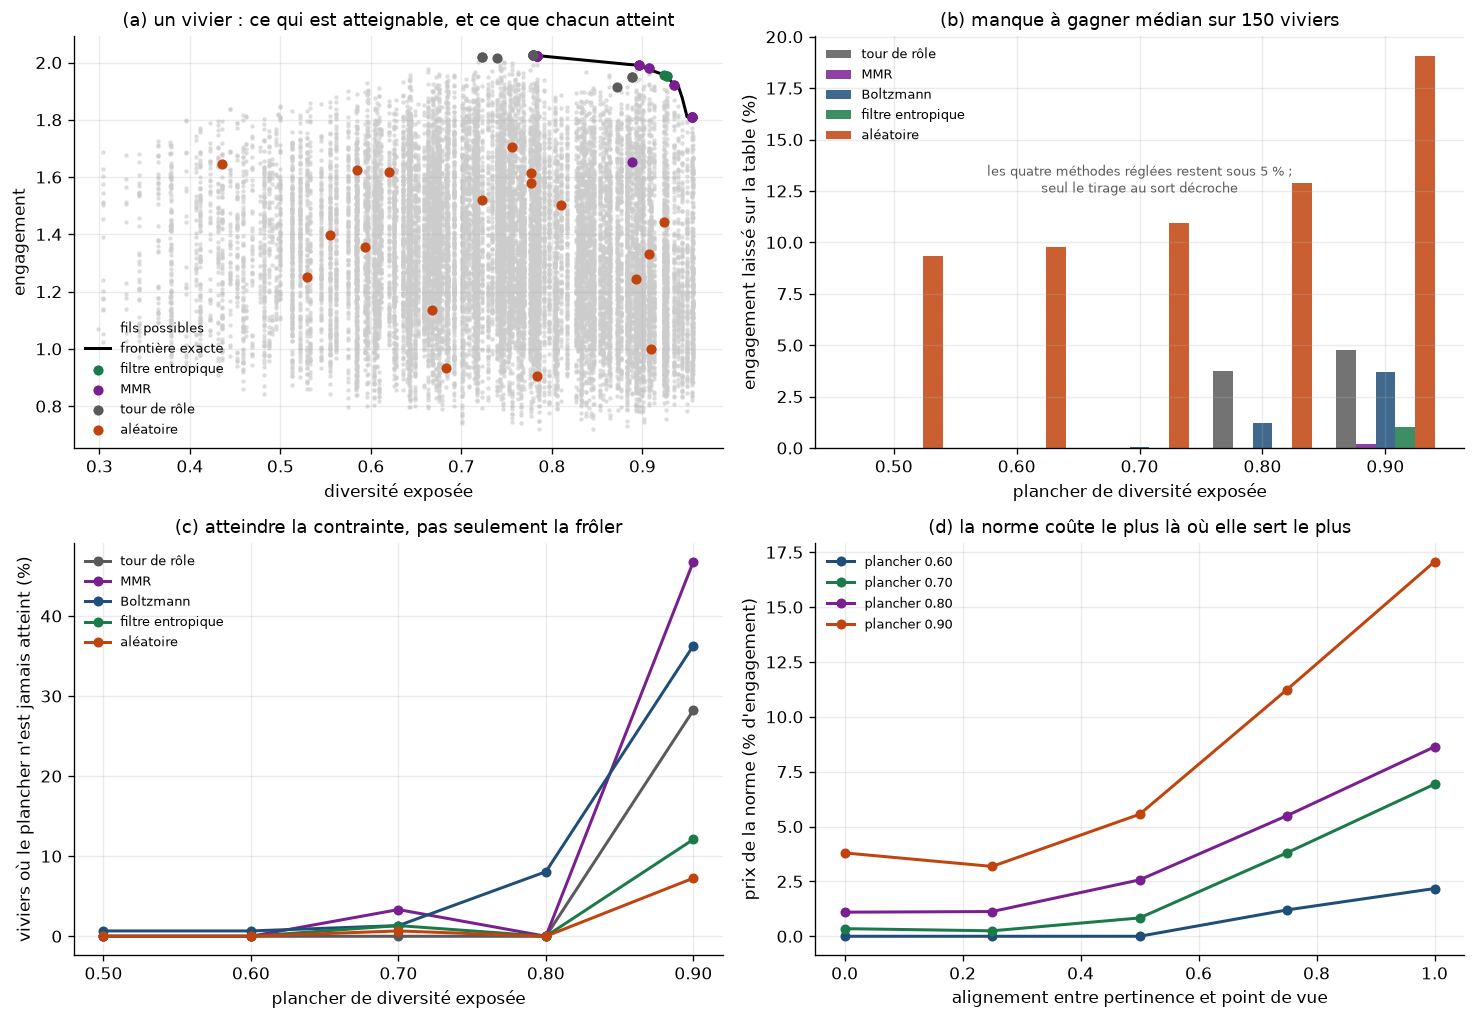

In [6]:
figure, axes = plt.subplots(2, 2, figsize=(12.4, 8.6))

# (a) un vivier : le nuage, la frontière, les méthodes
ax = axes[0, 0]
ax.scatter(cloud_exposure, cloud_engagement, s=3, color="#cccccc", alpha=0.5,
           label="fils possibles")
ax.plot([feed.exposure for feed in front], [feed.engagement for feed in front], "-",
        color="black", linewidth=1.8, label="frontière exacte")
for name in ("filtre entropique", "MMR", "tour de rôle", "aléatoire"):
    feeds = example_sweeps[name]
    ax.scatter([feed.exposure for feed in feeds], [feed.engagement for feed in feeds],
               s=26, color=COLOURS[name], label=name, zorder=3)
ax.set_xlabel("diversité exposée")
ax.set_ylabel("engagement")
ax.set_title("(a) un vivier : ce qui est atteignable, et ce que chacun atteint")
ax.legend(loc="lower left", fontsize=7.5)

# (b) manque à gagner médian
ax = axes[0, 1]
positions = np.arange(len(FLOORS))
width = 0.16
for index, name in enumerate(METHODS):
    values = [100 * np.median(shortfalls[name][floor]) if shortfalls[name][floor] else np.nan
              for floor in FLOORS]
    ax.bar(positions + (index - 2) * width, values, width=width, color=COLOURS[name],
           alpha=0.85, label=name)
ax.set_xticks(positions)
ax.set_xticklabels([f"{floor:.2f}" for floor in FLOORS])
ax.set_xlabel("plancher de diversité exposée")
ax.set_ylabel("engagement laissé sur la table (%)")
ax.set_title("(b) manque à gagner médian sur 150 viviers")
ax.legend(loc="upper left", fontsize=7.5)
ax.annotate("les quatre méthodes réglées restent sous 5 % ;\nseul le tirage au sort décroche",
            xy=(0.5, 0.62), xycoords="axes fraction", fontsize=8, color=PALETTE["neutral"],
            ha="center")

# (c) échecs à atteindre le plancher
ax = axes[1, 0]
for name in METHODS:
    ax.plot(positions, [100 * failures[name][floor] / max(eligible[floor], 1) for floor in FLOORS],
            "o-", color=COLOURS[name], markersize=5, label=name)
ax.set_xticks(positions)
ax.set_xticklabels([f"{floor:.2f}" for floor in FLOORS])
ax.set_xlabel("plancher de diversité exposée")
ax.set_ylabel("viviers où le plancher n'est jamais atteint (%)")
ax.set_title("(c) atteindre la contrainte, pas seulement la frôler")
ax.legend(loc="upper left", fontsize=7.5)

# (d) prix de la norme selon l'alignement
ax = axes[1, 1]
for floor, colour in zip(FLOORS[1:], (PALETTE["order"], PALETTE["remedy"], PALETTE["field"],
                                      PALETTE["disorder"]), strict=False):
    ax.plot(ALIGNMENTS,
            [100 * np.median(alignment_price[alignment][floor]) for alignment in ALIGNMENTS],
            "o-", color=colour, markersize=5, label=f"plancher {floor:.2f}")
ax.set_xlabel("alignement entre pertinence et point de vue")
ax.set_ylabel("prix de la norme (% d'engagement)")
ax.set_title("(d) la norme coûte le plus là où elle sert le plus")
ax.legend(loc="upper left", fontsize=8)

save_figure(figure, "fig19_lignes_de_base")
plt.show()

## 5. Ce que cette comparaison règle

**La dette est payée.** Le filtre a désormais été jugé contre quatre concurrents et contre la
borne exacte, sur 150 viviers tirés au sort, à cinq niveaux d'exigence.

**Le verdict est mitigé, et c'est le bon résultat.** Le filtre tient la frontière — ce n'était
pas gagné d'avance — mais il n'apporte rien qu'une heuristique de 1998 n'apporte déjà, sauf aux
planchers élevés, où il atteint la contrainte quatre fois plus souvent. Ce qui distingue ce
dépôt n'est donc pas son algorithme : c'est la **norme** et les **instruments qui la
vérifient**.

**Une conséquence pratique pour le mémorandum.** Puisqu'une heuristique publiée en 1998 suffit
à tenir un plancher de $0{,}80$ à $0{,}0\ \%$ d'engagement près, l'argument selon lequel une
norme de diversité exigerait de refondre les moteurs de recommandation ne tient pas. Ce qu'elle
exige, c'est de la mesurer.

**Et une réserve, la même que partout ailleurs.** Ces viviers sont synthétiques : dix contenus,
quatre points de vue, six positions. La frontière exacte n'existe qu'à cette échelle — c'est le
prix de l'exactitude. Rien n'assure que les rangs relatifs des méthodes se transportent à un
vivier de mille contenus, et l'affirmer demanderait précisément la donnée qui manque.